SKILL-1

In [ ]:
import torch

inputs = torch.tensor([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=torch.float32)
expected_outputs = torch.tensor([0, 0, 0, 1], dtype=torch.float32)

weights = torch.tensor([0.6, 0.6    ], requires_grad=False)
threshold = 0.8
print("Inputs\t \tWeights\t \tWeighted Sum\t Threshold \t Output")

for i, input_pair in enumerate(inputs):
    weighted_sum = torch.dot(input_pair, weights)
    output = 1.0 if weighted_sum > threshold else 0.0
    print(f"{input_pair.numpy()}\t{weights.numpy()}\t{weighted_sum.item():.2f}\t\t{threshold}\t\t{int(output)}")
import torch

num1 = torch.tensor(5)
num2 = torch.tensor(3)

result = num1 + num2
print(result)

import torch

num1 = torch.tensor(5)
num2 = torch.tensor(3)


result = num1 + num2
print(result)
import torch

numbers = torch.randint(1, 10, (5,))

result = torch.sum(numbers)
print("Random numbers:", numbers)
print("Sum of numbers:", result)
import torch

numbers = torch.tensor([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

result = torch.sum(numbers)
print("Numbers:", numbers)
print("Sum of numbers:", result)
import torch

numbers = torch.randint(1, 10, (10,))


result = torch.sum(numbers)
print("Random numbers:", numbers)
print("Sum of numbers:", result)


Inputs	 	Weights	 	Weighted Sum	 Threshold 	 Output
[0. 0.]	[0.6 0.6]	0.00		0.8		0
[0. 1.]	[0.6 0.6]	0.60		0.8		0
[1. 0.]	[0.6 0.6]	0.60		0.8		0
[1. 1.]	[0.6 0.6]	1.20		0.8		1
tensor(8)
tensor(8)
Random numbers: tensor([6, 4, 7, 6, 8])
Sum of numbers: tensor(31)
Numbers: tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
Sum of numbers: tensor(55)
Random numbers: tensor([7, 2, 2, 7, 1, 5, 9, 4, 4, 9])
Sum of numbers: tensor(50)


SKILL-2

Create of simple web application using pytorch and flask for simple Neural network program

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim


class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.layer1 = nn.Linear(1, 10)
        self.layer2 = nn.Linear(10, 1)
        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.activation(self.layer1(x))
        x = self.layer2(x)
        return x

model = SimpleNN()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

x_train = torch.linspace(-10, 10, 100).reshape(-1, 1)
y_train = 2 * x_train + 3 + torch.randn_like(x_train) * 0.5

for epoch in range(1000):
    optimizer.zero_grad()
    predictions = model(x_train)
    loss = criterion(predictions, y_train)
    loss.backward()
    optimizer.step()

torch.save(model.state_dict(), "model.pth")

print("Model trained and saved as 'model.pth'")


Model trained and saved as 'model.pth' ✅


In [ ]:
import os

zip_path = "/content/plant-seedlings-classification (1).zip"

if os.path.exists(zip_path):
    print(f"✅ File found: {zip_path}")
else:
    print("❌ File not found! Please upload it again.")


✅ File found: /content/plant-seedlings-classification (1).zip


In [ ]:
new_zip_path = "/content/plant-seedlings.zip"
os.rename(zip_path, new_zip_path)
print(f"✅ Renamed file to: {new_zip_path}")


✅ Renamed file to: /content/plant-seedlings.zip


In [ ]:
import zipfile

extract_path = "/content/plant-seedlings-dataset"

# Create the directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Extract the ZIP file
with zipfile.ZipFile(new_zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"✅ Extraction complete! Files are saved in: {extract_path}")


✅ Extraction complete! Files are saved in: /content/plant-seedlings-dataset


SKILL-3

Data loading and preprocessing on project datset

✅ Dataset found at: /content/plant-seedlings-dataset
Classes found: ['test', 'train']
✅ Training samples: 4435
✅ Validation samples: 1109


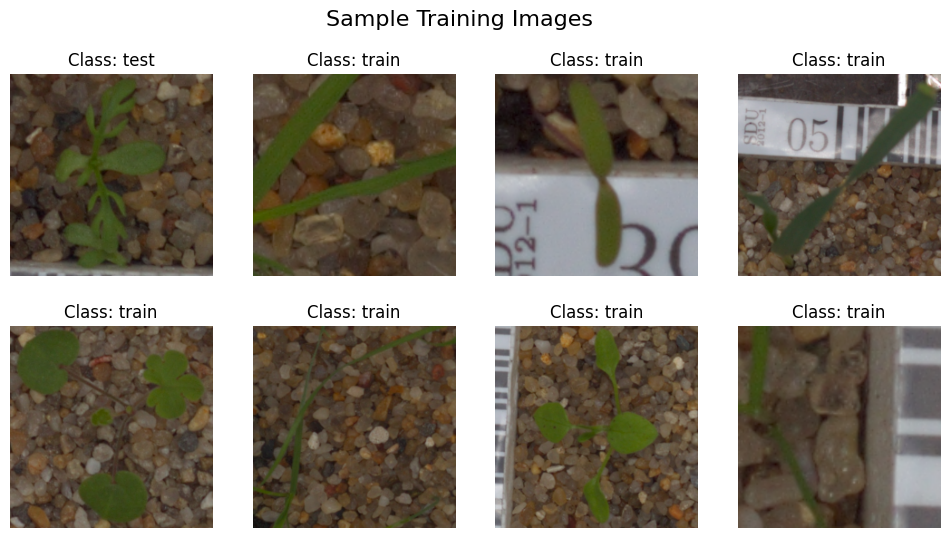

In [ ]:

import torch
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

dataset_path = "/content/plant-seedlings-dataset"

if not os.path.exists(dataset_path):
    print(" Dataset path does not exist! Check extraction.")
else:
    print(" Dataset found at:", dataset_path)


train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


dataset = ImageFolder(root=dataset_path, transform=train_transforms)


print(f"Classes found: {dataset.classes}")


train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

val_dataset.dataset.transform = val_transforms

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f" Training samples: {len(train_dataset)}")
print(f" Validation samples: {len(val_dataset)}")

def imshow_without_torchvision(images, labels):
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    fig.suptitle("Sample Training Images", fontsize=16)

    for i, ax in enumerate(axes.flat):
        if i < len(images):
            img = images[i].numpy().transpose((1, 2, 0))
            img = img * 0.5 + 0.5
            ax.imshow(img)
            ax.set_title(f"Class: {dataset.classes[labels[i]]}")
            ax.axis("off")

    plt.show()


dataiter = iter(train_loader)
images, labels = next(dataiter)


imshow_without_torchvision(images[:8], labels[:8])


SKILL-4

Implement Sequential model for classify the given Project data into binary /multiclass

 Dataset found at: /content/plant-seedlings-dataset
Classes found: ['test', 'train']
 Training samples: 4435
 Validation samples: 1109
Epoch [1/10] - Train Loss: 0.4415, Val Loss: 0.4302, Accuracy: 84.31%
Epoch [2/10] - Train Loss: 0.3937, Val Loss: 0.4390, Accuracy: 84.31%
Epoch [3/10] - Train Loss: 0.3886, Val Loss: 0.4137, Accuracy: 84.31%
Epoch [4/10] - Train Loss: 0.3760, Val Loss: 0.4005, Accuracy: 84.31%
Epoch [5/10] - Train Loss: 0.3716, Val Loss: 0.4099, Accuracy: 84.31%
Epoch [6/10] - Train Loss: 0.3600, Val Loss: 0.4056, Accuracy: 84.31%
Epoch [7/10] - Train Loss: 0.3466, Val Loss: 0.4023, Accuracy: 84.22%
Epoch [8/10] - Train Loss: 0.3139, Val Loss: 0.3799, Accuracy: 84.13%
Epoch [9/10] - Train Loss: 0.2872, Val Loss: 0.4008, Accuracy: 84.58%
Epoch [10/10] - Train Loss: 0.2513, Val Loss: 0.6419, Accuracy: 84.22%


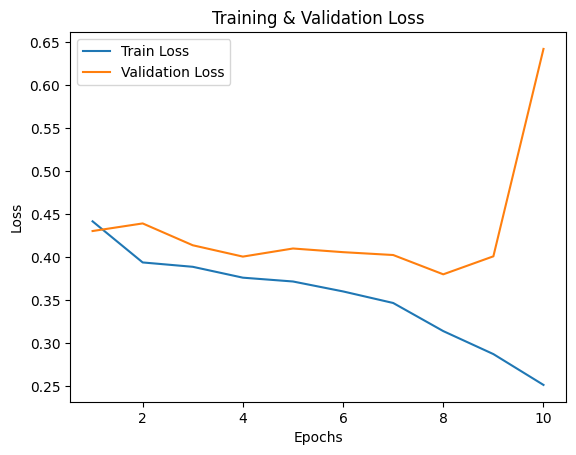

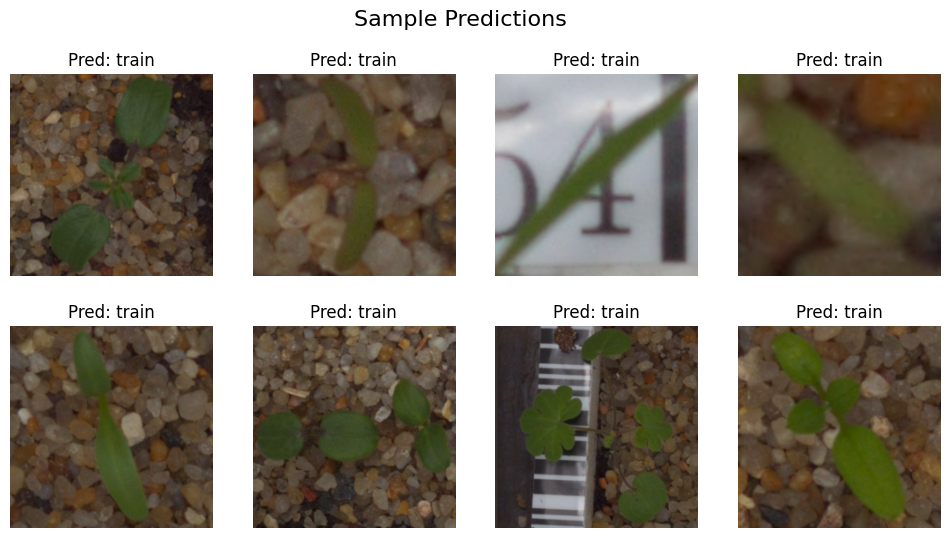

NameError: name 'epoch' is not defined

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import os
import matplotlib.pyplot as plt
import numpy as np


dataset_path = "/content/plant-seedlings-dataset"


if not os.path.exists(dataset_path):
    print(" Dataset path does not exist! Check extraction.")
else:
    print(" Dataset found at:", dataset_path)

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

dataset = ImageFolder(root=dataset_path, transform=train_transforms)
num_classes = len(dataset.classes)
print(f"Classes found: {dataset.classes}")

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

val_dataset.dataset.transform = val_transforms

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f" Training samples: {len(train_dataset)}")
print(f" Validation samples: {len(val_dataset)}")

class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNModel(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        val_loss = 0.0
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        accuracy = 100 * correct / total

        print(f"Epoch [{epoch+1}/{epochs}] - "
              f"Train Loss: {avg_train_loss:.4f}, "
              f"Val Loss: {avg_val_loss:.4f}, "
              f"Accuracy: {accuracy:.2f}%")

    return train_losses, val_losses

epochs = 10
train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, epochs)

plt.plot(range(1, epochs+1), train_losses, label="Train Loss")
plt.plot(range(1, epochs+1), val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.show()
def test_model(model, dataloader, num_images=8):
    model.eval()
    images, labels = next(iter(dataloader))
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        _, predictions = torch.max(outputs, 1)

    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    fig.suptitle("Sample Predictions", fontsize=16)

    for i, ax in enumerate(axes.flat):
        if i < num_images:
            img = images[i].cpu().numpy().transpose((1, 2, 0))
            img = img * 0.5 + 0.5
            ax.imshow(img)
            ax.set_title(f"Pred: {dataset.classes[predictions[i].item()]}")
            ax.axis("off")

    plt.show()

test_model(model, val_loader)

def save_model(model, optimizer, path="plant_seedlings_model.pth"):
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch': epoch,
    }, path)
    print(f"Model saved to {path}")


save_model(model, optimizer, path="plant_seedlings_model.pth")


In [ ]:
!unzip -q "/content/plant-seedlings-classification.zip" -d "/content/dataset"

error [/content/plant-seedlings-classification.zip]:  missing 122683392 bytes in zipfile
  (attempting to process anyway)
error: invalid zip file with overlapped components (possible zip bomb)


SKILL- 10

Create a Recurrent neural network to classify given Project data

Epoch 1/3


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5560 - loss: 0.6756 - val_accuracy: 0.6420 - val_loss: 0.6428
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6829 - loss: 0.5883 - val_accuracy: 0.7819 - val_loss: 0.4980
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.7794 - loss: 0.4945 - val_accuracy: 0.8560 - val_loss: 0.3285
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8502 - loss: 0.3378

Test Accuracy: 0.8560

Plotting Top Words in POSITIVE Reviews...


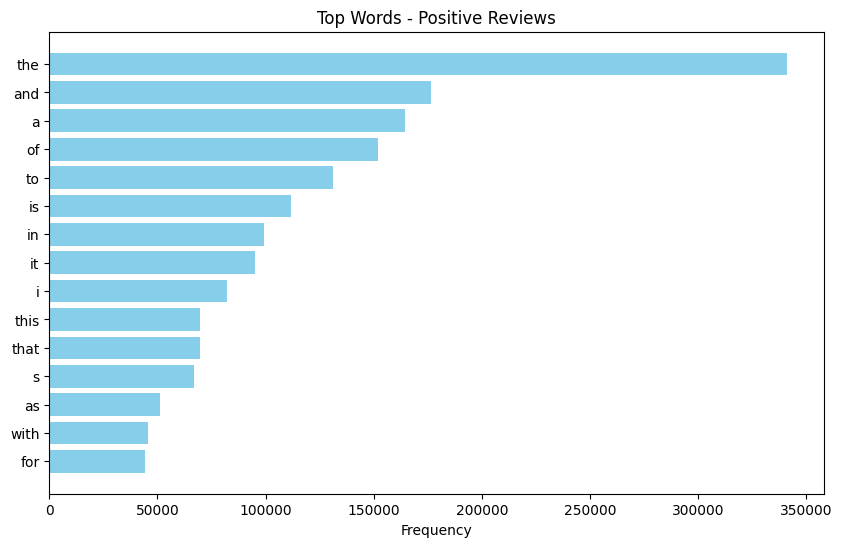

Plotting Top Words in NEGATIVE Reviews...


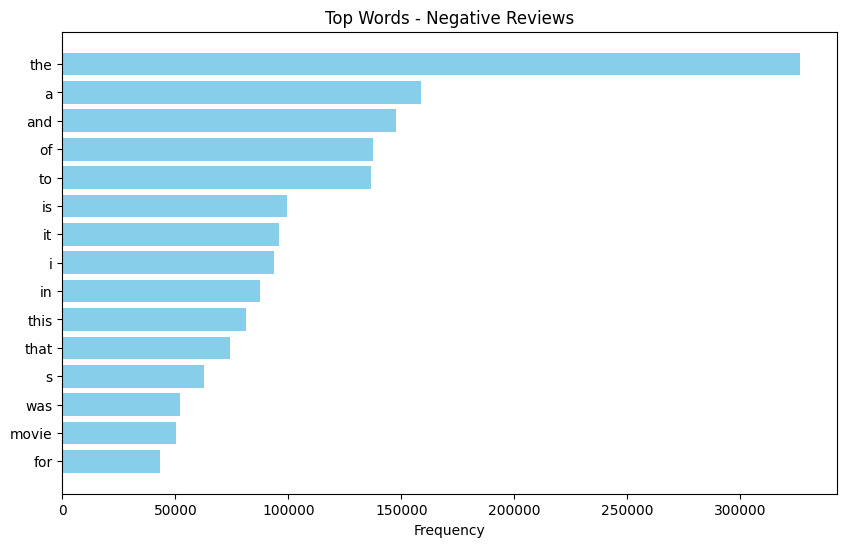

In [ ]:
import pandas as pd
import numpy as np
import re
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from collections import Counter

# 1. Load the IMDB Movie Reviews Dataset
df = pd.read_csv('/content/dataset/IMDB Dataset.csv')  # Change this to your dataset path

# 2. Clean the text data
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # Remove non-alphabetic characters
    text = text.lower()  # Convert text to lowercase
    return text

df['review'] = df['review'].apply(clean_text)  # Apply cleaning function to reviews

# 3. Encode Labels (positive/negative sentiment)
label_encoder = LabelEncoder()
df['sentiment'] = label_encoder.fit_transform(df['sentiment'])  # pos=1, neg=0

# 4. Tokenize and Pad Sequences
vocab_size = 10000  # Maximum number of words to consider
max_length = 200    # Maximum length of each review

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")  # Tokenizer setup
tokenizer.fit_on_texts(df['review'])  # Fit tokenizer on the reviews

# Convert reviews into sequences
X = tokenizer.texts_to_sequences(df['review'])
X = pad_sequences(X, maxlen=max_length, padding='post')  # Pad sequences to ensure uniform length
y = df['sentiment'].values  # Sentiment labels

# 5. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Build the RNN Model with LSTM
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),  # Embedding layer to represent words as vectors
    LSTM(128, return_sequences=False),  # LSTM layer for sequential data
    Dropout(0.5),  # Dropout layer for regularization
    Dense(1, activation='sigmoid')  # Output layer with sigmoid activation for binary classification
])

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 7. Train the model
history = model.fit(X_train, y_train, epochs=3, batch_size=64, validation_data=(X_test, y_test))

# 8. Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'\nTest Accuracy: {accuracy:.4f}\n')

# 9. Plot a Bar Chart of Most Frequent Words in Positive and Negative Reviews
# Function to plot a bar chart of top words
def plot_top_words(reviews, title, n=15):
    all_words = ' '.join(reviews).split()  # Split reviews into words
    word_counts = Counter(all_words).most_common(n)  # Get the most common words

    # Unzip the list of tuples into two separate lists (words and counts)
    words, counts = zip(*word_counts)

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.barh(words[::-1], counts[::-1], color='skyblue')  # Reverse to display most frequent words at the top
    plt.xlabel('Frequency')
    plt.title(title)
    plt.show()

# Plot bar charts for positive and negative reviews
print("Plotting Top Words in POSITIVE Reviews...")
plot_top_words(df[df['sentiment'] == 1]['review'], 'Top Words - Positive Reviews')

print("Plotting Top Words in NEGATIVE Reviews...")
plot_top_words(df[df['sentiment'] == 0]['review'], 'Top Words - Negative Reviews')


Skill-11 Generate LSTM. Model for classification and to identify patterns from the project data set

In [ ]:
import pandas as pd
import numpy as np
import re
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from collections import Counter

df = pd.read_csv('/content/dataset/IMDB Dataset.csv')

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    return text

df['review'] = df['review'].apply(clean_text)

label_encoder = LabelEncoder()
df['sentiment'] = label_encoder.fit_transform(df['sentiment'])  # pos=1, neg=0

vocab_size = 10000
max_length = 200

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(df['review'])

X = tokenizer.texts_to_sequences(df['review'])
X = pad_sequences(X, maxlen=max_length, padding='post')
y = df['sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=3, batch_size=64, validation_data=(X_test, y_test))

loss, accuracy = model.evaluate(X_test, y_test)
print(f'\n Test Accuracy: {accuracy:.4f}\n')

df['sentiment_label'] = df['sentiment'].map({1: 'positive', 0: 'negative'})

print("\n First 2 Reviews and Their Sentiment:\n")
for i in range(2):
    print(f"Review #{i+1}:")
    print(df['review'].iloc[i])
    print(f"Sentiment: {df['sentiment_label'].iloc[i]}")
    print("-" * 60)

def get_top_words(reviews, n=15):
    all_words = ' '.join(reviews).split()
    common_words = Counter(all_words).most_common(n)
    return common_words

print("\n Top words in NEGATIVE reviews:")
neg_reviews = df[df['sentiment'] == 0]['review']
for word, freq in get_top_words(neg_reviews):
    print(f"{word}: {freq}")


Epoch 1/3


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5494 - loss: 0.6799 - val_accuracy: 0.6171 - val_loss: 0.6133
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6496 - loss: 0.6143 - val_accuracy: 0.6799 - val_loss: 0.6192
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.7326 - loss: 0.5326 - val_accuracy: 0.8620 - val_loss: 0.3201
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8592 - loss: 0.3265

 Test Accuracy: 0.8620


 First 2 Reviews and Their Sentiment:

Review #1:
one of the other reviewers has mentioned that after watching just   oz episode you ll be hooked  they are right  as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence  which set in right from the word go  trust me  this is not a show for the faint hearted or timid  this show pulls no punches with regards to drugs  sex or violence  its is hardcore  in the classic use of the word it is calle

LAB-12 Use autoencoders to compress the images and implement Resnet to classify data

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import numpy as np

# 1. Load CIFAR-10 Dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

input_img = layers.Input(shape=(32, 32, 3))

# Encoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)  # Output: (8, 8, 64)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

print("\n🔧 Training Autoencoder...")
autoencoder.fit(x_train, x_train, epochs=10, batch_size=128, shuffle=True, validation_data=(x_test, x_test))

encoder = models.Model(inputs=input_img, outputs=encoded)
x_train_encoded = encoder.predict(x_train)
x_test_encoded = encoder.predict(x_test)

print(f" Encoded feature shape: {x_train_encoded.shape}")

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense

resnet_input = Input(shape=(8, 8, 64))
resnet_base = ResNet50(include_top=False, weights=None, input_tensor=resnet_input)

x = GlobalAveragePooling2D()(resnet_base.output)
output = Dense(10, activation='softmax')(x)

resnet_model = models.Model(inputs=resnet_input, outputs=output)
resnet_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("\n🔧 Training ResNet on compressed features...")
resnet_model.fit(x_train_encoded, y_train, validation_data=(x_test_encoded, y_test), epochs=10, batch_size=64)

loss, acc = resnet_model.evaluate(x_test_encoded, y_test)
print(f"\n Final Accuracy (ResNet on compressed features): {acc:.4f}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step

🔧 Training Autoencoder...
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - loss: 0.0202 - val_loss: 0.0055
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0054 - val_loss: 0.0045
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0044 - val_loss: 0.0043
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0041 - val_loss: 0.0037
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0038 - val_loss: 0.0035
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0036 - val_loss: 0.0037
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0034 - val_loss: 0.0032
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0032 - val_loss: 0.0030
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0030 - val_loss: 0.0030
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0029 - val_loss: 0.0028
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
313/